In [10]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.stats import spearmanr

In [70]:
## Single gene-trait association plot
gene_name = 'LDLR'  # Kircher: [231, 87]
# gene_name = 'GP1BB' # Kircher: [273, 112]

gene_name = 'CLEC11A'
# gene_name = 'APOB'

In [71]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac
config_path = "/home/dnanexus/ukbgym/config_olink.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",-1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",-1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",-1
"""splicing""","""absplice2_max""","""#1E8449""","""AbSplice2 (max)""",-1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1


In [72]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet").filter(pl.col('gene_name') == gene_name)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
variant_class = "intronic"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

min_range = -500
max_range = +0
abs_phenotypes = False

anno_wide = (
    anno
    .filter(
        # filter_expression &
        # (pl.col('consequence_splice_acceptor_variant') == 1) | (pl.col('consequence_splice_donor_variant') == 1)
        (pl.col('dist_to_tss') >= min_range) &
        (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    .drop_nulls()
)

# Create a lazy frame with the unique keys
anno_keys = anno_wide.select(pl.col('id').unique()).lazy()

# Get gene_id to get olink protein
olink_prot = anno_wide['region'].unique()[0] + '_olink'

anno_wide

delta_score,gene_length,id,TSS,pangolin_score,am_pathogenicity,verphylop,Strand,gene_name,gpn_star_llr_calibrated_mean,dist_to_tss,region,gpn_score,abexp_min,loftee_hc,esmscoremissense,cadd_raw,mamphylop,promoterai,promoterai_abs,absplice_dna_max,absplice2_max
f32,i64,str,i64,f32,f32,f32,cat,str,f64,i64,str,f32,f64,i8,f32,f32,f32,f32,f32,f32,f32
0.0,2346,"""chr19:50722932:C:T""",50723363,0.0,0.0,-0.231,"""+""","""CLEC11A""",-0.842071,-431,"""ENSG00000105472""",-2.9,0.002221,0,0.0,0.534661,-0.49,-0.0286,0.0286,0.0,0.0
0.0,2346,"""chr19:50723345:G:C""",50723363,0.0,0.0,-0.232,"""+""","""CLEC11A""",-2.533045,-18,"""ENSG00000105472""",-3.44,-0.005749,0,0.0,0.855531,-0.04,0.1831,0.1831,0.0,0.0
0.0,2346,"""chr19:50723317:C:T""",50723363,0.0,0.0,1.879,"""+""","""CLEC11A""",-4.377247,-46,"""ENSG00000105472""",-5.22,-0.003532,0,0.0,2.918353,1.49,-0.4217,0.4217,0.0,0.0
0.0,2346,"""chr19:50723162:T:C""",50723363,0.0,0.0,0.547,"""+""","""CLEC11A""",2.213028,-201,"""ENSG00000105472""",-0.0,-0.000569,0,0.0,1.086154,0.824,0.0754,0.0754,0.0,0.0
0.0,2346,"""chr19:50723331:C:T""",50723363,0.0,0.0,2.341,"""+""","""CLEC11A""",-2.903534,-32,"""ENSG00000105472""",-4.72,-0.012423,0,0.0,1.794273,2.087,-0.1306,0.1306,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,2346,"""chr19:50722907:G:A""",50723363,0.0,0.0,4.552,"""+""","""CLEC11A""",-1.298528,-456,"""ENSG00000105472""",-3.32,-0.000569,0,0.0,1.468675,4.029,-0.0007,0.0007,0.0,0.0
0.0,2346,"""chr19:50723196:G:T""",50723363,0.0,0.0,1.578,"""+""","""CLEC11A""",-5.175989,-167,"""ENSG00000105472""",-3.04,-0.000569,0,0.0,2.163369,1.908,-0.3444,0.3444,0.0,0.0
0.0,2346,"""chr19:50722958:G:T""",50723363,0.0,0.0,0.805,"""+""","""CLEC11A""",-1.718355,-405,"""ENSG00000105472""",-1.58,0.000744,0,0.0,0.649358,0.94,-0.0062,0.0062,0.0,0.0


In [73]:
# new_anno = pl.scan_parquet("/home/dnanexus/data_dir/abexp1.1_annotations_all_ukb_vars_genebass1e6.parquet")
# # new_anno.head().collect()
# new_anno = new_anno.select(['id', 'region', 'abexp_whole_blood']).collect()
# new_anno = new_anno.filter(pl.col('abexp_whole_blood').is_not_null())

# anno_wide = anno_wide.join(new_anno, on=['id', 'region'], how='left').filter(pl.col('abexp_whole_blood').is_not_null())

# existing_annos += ['abexp_whole_blood']

# anno_wide

In [74]:
melted_anno = anno_wide.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:50722932:C:T""","""ENSG00000105472""","""loftee_hc""",0.0
"""chr19:50723345:G:C""","""ENSG00000105472""","""loftee_hc""",0.0
"""chr19:50723317:C:T""","""ENSG00000105472""","""loftee_hc""",0.0
"""chr19:50723162:T:C""","""ENSG00000105472""","""loftee_hc""",0.0
"""chr19:50723331:C:T""","""ENSG00000105472""","""loftee_hc""",0.0
…,…,…,…
"""chr19:50722907:G:A""","""ENSG00000105472""","""promoterai""",-0.0007
"""chr19:50723196:G:T""","""ENSG00000105472""","""promoterai""",-0.3444
"""chr19:50722958:G:T""","""ENSG00000105472""","""promoterai""",-0.0062


In [75]:
# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

olink_appv = (
    olink_appv
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
    .rename({
        'phenotype': 'olink_prot',
        'mean_pheno_value': 'mean_olink_value',
        'std_pheno_value': 'std_olink_value',
    })
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac) &
        (pl.col('olink_prot') == olink_prot)
    )
)

# Merge olink, phenotype, and annotation data
og_df = (
    olink_appv
    .join(
        melted_anno.lazy(),
        on="id",
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).lazy(),
        on=['id', 'region'],
        how='inner'
    )
    .collect(engine='streaming')
)

og_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr19:50723326:A:G""","""ENSG00000105472_olink""",1,0.715772,null,"""ENSG00000105472""","""cadd_raw""",1.952921,50723363,"""+""",2346,"""CLEC11A""",-37
"""chr19:50723326:A:G""","""ENSG00000105472_olink""",1,0.715772,null,"""ENSG00000105472""","""loftee_hc""",0.0,50723363,"""+""",2346,"""CLEC11A""",-37
"""chr19:50723326:A:G""","""ENSG00000105472_olink""",1,0.715772,null,"""ENSG00000105472""","""am_pathogenicity""",0.0,50723363,"""+""",2346,"""CLEC11A""",-37
"""chr19:50723326:A:G""","""ENSG00000105472_olink""",1,0.715772,null,"""ENSG00000105472""","""esmscoremissense""",0.0,50723363,"""+""",2346,"""CLEC11A""",-37
"""chr19:50723326:A:G""","""ENSG00000105472_olink""",1,0.715772,null,"""ENSG00000105472""","""verphylop""",0.688,50723363,"""+""",2346,"""CLEC11A""",-37
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:50723059:C:G""","""ENSG00000105472_olink""",2,-0.004729,0.085964,"""ENSG00000105472""","""abexp_min""",0.002221,50723363,"""+""",2346,"""CLEC11A""",-304
"""chr19:50723059:C:G""","""ENSG00000105472_olink""",2,-0.004729,0.085964,"""ENSG00000105472""","""delta_score""",0.0,50723363,"""+""",2346,"""CLEC11A""",-304
"""chr19:50723059:C:G""","""ENSG00000105472_olink""",2,-0.004729,0.085964,"""ENSG00000105472""","""promoterai_abs""",0.004,50723363,"""+""",2346,"""CLEC11A""",-304


In [76]:
# # Join with experimental data
# exp_data = pl.read_csv('/home/dnanexus/data_dir/exp_data/kircher_all_enhancers_and_promoters.tsv', separator='\t').rename({
#     'locus': 'gene_name'
# }).with_columns(
#     id=pl.col('Chromosome')+':'+pl.col('variant_pos').cast(pl.Utf8)+':'+pl.col('ref')+':'+pl.col('alt')
# ).select(
#     ['gene_name', 'id', 'log2FC', 'variant_pos']
# ).unique().filter(
#     pl.col('gene_name') == gene_name
# )

# # exp_data['variant_pos'].min()

# # Merge phenodata with exp_data
# og_df = og_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
# og_df

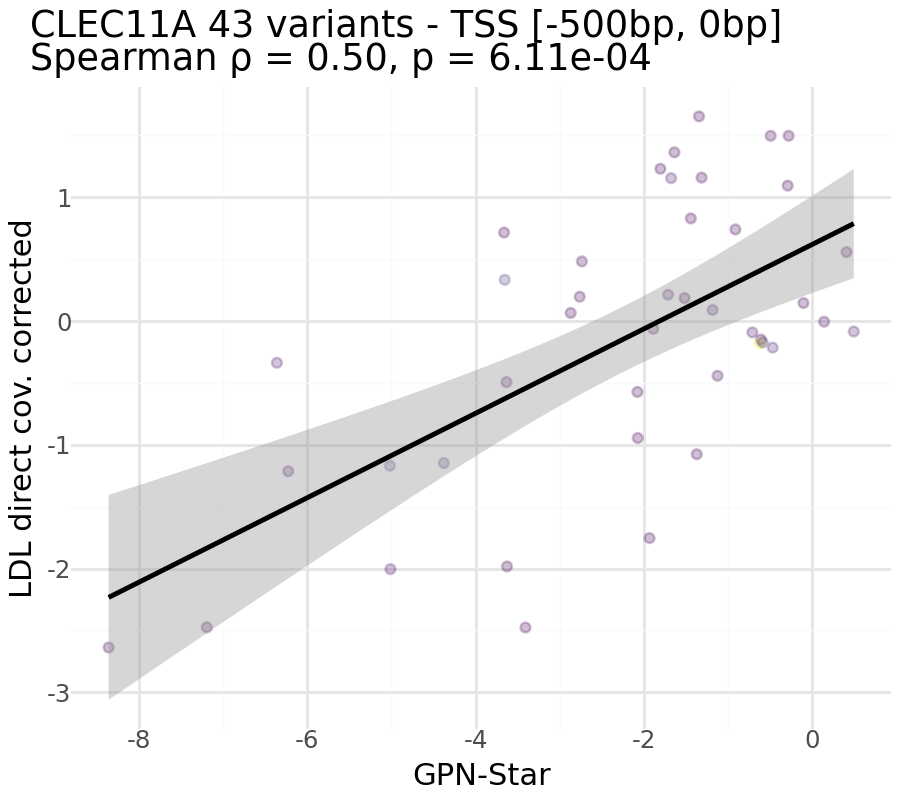

In [84]:
annotation = 'gpn_star_llr_calibrated_mean'
# annotation = 'cadd_raw'
# annotation = 'promoterai'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    og_df
    .filter(
        (pl.col('annotation') == annotation)
    )
    .drop_nulls(subset=['annotation_score', 'mean_olink_value'])
)

spearman_corr, p_value = spearmanr(
        plot_df['annotation_score'],
        plot_df['mean_olink_value']
    )

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_olink_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    stat_smooth(method='glm', se=True) +
    # scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y="LDL direct cov. corrected",
        title=f"{gene_name} {plot_df.shape[0]} variants - TSS [{min_range}bp, {max_range}bp] \
            \nSpearman ρ = {spearman_corr:.2f}, p = {p_value:.2e}"
            # {variant_class} variants\
    ) +
    theme(
        figure_size=(4.5, 4),
        legend_position='none'
    )
)

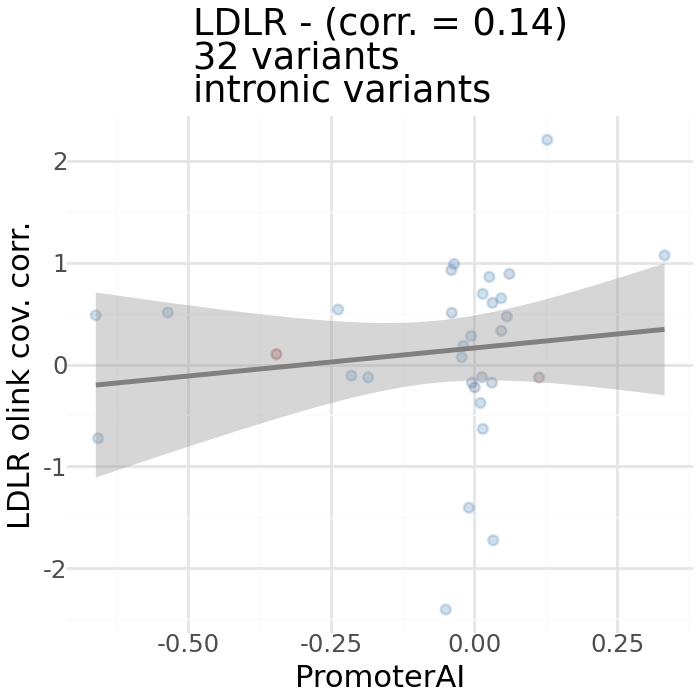

In [69]:
# annotation = 'gpn_star_llr_calibrated_mean'
annotation = 'cadd_raw'
annotation = 'promoterai'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    og_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_olink_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='glm', se=True, color='gray') +
    scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{gene_name} olink cov. corr.",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_olink_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants \
        \n{variant_class} variants",
        # \n[{min_range}bp, {max_range}bp]"
    ) +
    theme(
        figure_size=(3.5, 3.5),
        legend_position='none'
    )
)

In [78]:

plot_df = (
    og_df
    .select(['id', 'log2FC', 'mean_olink_value', 'n_individuals'])
    .unique()
    # .filter(
    #     (pl.col('annotation') == annotation)
    # )
)

(
    ggplot(plot_df, aes(x='log2FC', y='mean_olink_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='glm', se=True, color='gray') +
    scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"log2FC (Kircher et al.)",
        y=f"{gene_name} olink cov. corr.",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('log2FC', 'mean_olink_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants \
        \n[{min_range}bp, {max_range}bp]"
    ) +
    theme(
        figure_size=(3.5, 3.5),
        legend_position='none'
    )
)

ColumnNotFoundError: unable to find column "log2FC"; valid columns: ["id", "olink_prot", "n_individuals", "mean_olink_value", "std_olink_value", "region", "annotation", "annotation_score", "TSS", "Strand", "gene_length", "gene_name", "dist_to_tss"]

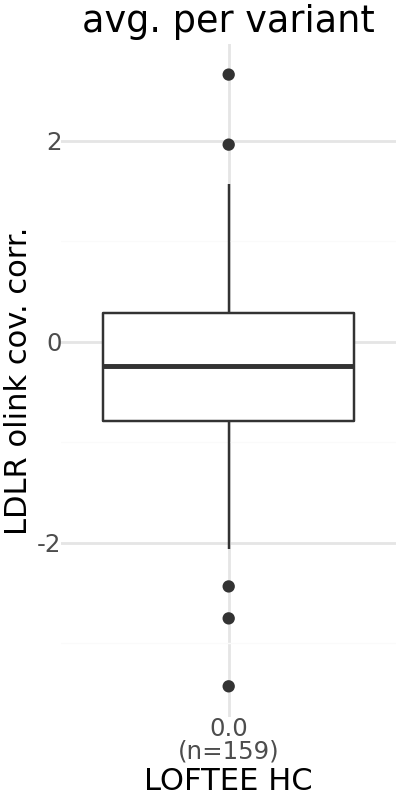

In [13]:
annotation = 'loftee_hc'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    og_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

summary_labels = (
    plot_df
    .group_by(['annotation_score'])
    .agg(n_vars = pl.col('id').len())
    .with_columns(n_label = pl.col('annotation_score').cast(pl.Utf8) + '\n(n=' + pl.col('n_vars').cast(pl.Utf8) + ')')
)

plot_df = plot_df.join(summary_labels, on='annotation_score', how='left')

(
    ggplot(plot_df, aes(x='n_label', y='mean_olink_value')) +
    geom_boxplot(aes(group='n_label')) +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{gene_name} olink cov. corr.",
        title="avg. per variant"
    ) +
    theme(figure_size=(2, 4))
)

In [33]:
phenotype = 'ldl_direct_int'

# Merge olink, genotype and phenotype data
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet")

appv = (
    appv
    .join(
        og_df[['id']].unique().lazy(), on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac) &
        (pl.col('phenotype') == phenotype)
    )
)

ogp_df = (
    og_df.lazy()
    .join(
            appv,
            on="id",
            how="inner"
    )
    .collect(engine='streaming')
    .rename({
        'n_individuals_right': 'n_individuals_appv',
    })
)

ogp_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss,phenotype,n_individuals_appv,mean_pheno_value,std_pheno_value
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64,str,u32,f32,f32
"""chr19:11089502:G:T""","""ENSG00000130164_olink""",1,-0.055333,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",0.25179,11089461,"""+""",44360,"""LDLR""",41,"""ldl_direct_int""",1,-0.019057,null
"""chr19:11089461:G:A""","""ENSG00000130164_olink""",1,-0.108945,null,"""ENSG00000130164""","""esmscoremissense""",0.0,11089461,"""+""",44360,"""LDLR""",0,"""ldl_direct_int""",15,-0.115859,0.683342
"""chr19:11089461:G:A""","""ENSG00000130164_olink""",1,-0.108945,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",-2.707564,11089461,"""+""",44360,"""LDLR""",0,"""ldl_direct_int""",15,-0.115859,0.683342
"""chr19:11089364:C:T""","""ENSG00000130164_olink""",1,0.540594,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",-2.787185,11089461,"""+""",44360,"""LDLR""",-97,"""ldl_direct_int""",2,0.063061,0.10452
"""chr19:11089474:G:A""","""ENSG00000130164_olink""",1,0.952203,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",-1.547741,11089461,"""+""",44360,"""LDLR""",13,"""ldl_direct_int""",1,0.081006,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11089523:G:A""","""ENSG00000130164_olink""",1,-0.8685,null,"""ENSG00000130164""","""promoterai_abs""",0.0621,11089461,"""+""",44360,"""LDLR""",62,"""ldl_direct_int""",3,0.112577,0.863519
"""chr19:11089428:T:C""","""ENSG00000130164_olink""",35,0.101753,1.181681,"""ENSG00000130164""","""promoterai_abs""",0.346,11089461,"""+""",44360,"""LDLR""",-33,"""ldl_direct_int""",284,0.230678,1.087918
"""chr19:11089428:T:C""","""ENSG00000130164_olink""",35,0.101753,1.181681,"""ENSG00000130164""","""promoterai_under""",-0.346,11089461,"""+""",44360,"""LDLR""",-33,"""ldl_direct_int""",284,0.230678,1.087918


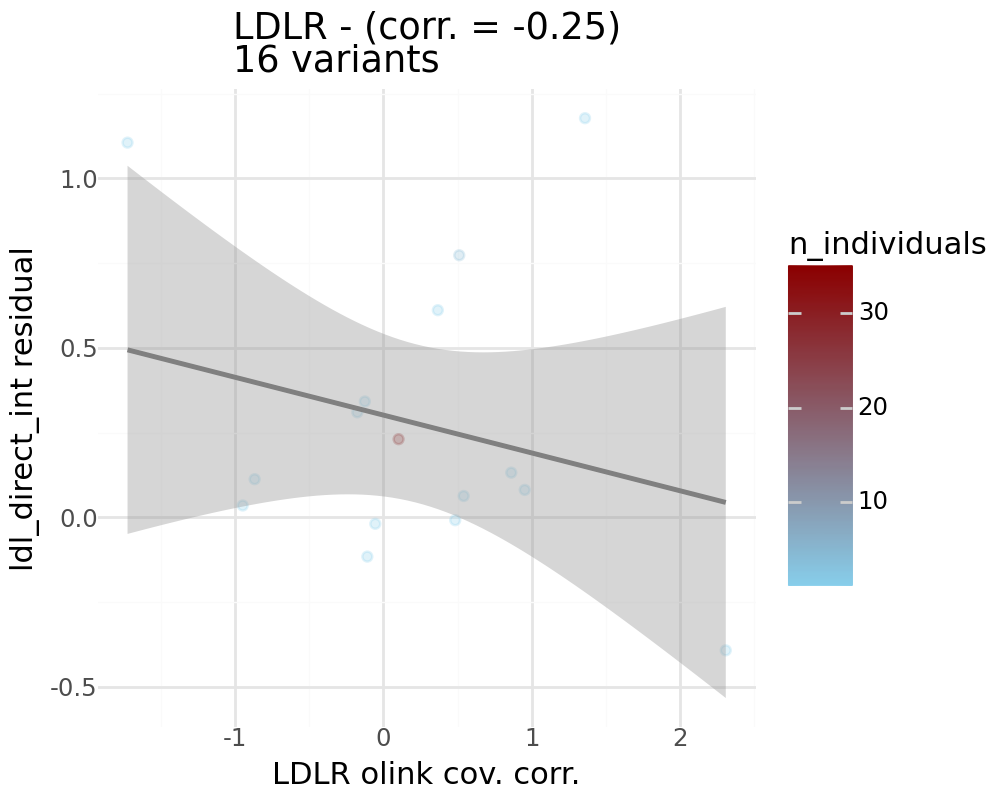

In [34]:
plot_df = ogp_df[['id', 'mean_olink_value', 'mean_pheno_value', 'n_individuals']].unique()

(
    ggplot(plot_df, aes(x='mean_olink_value', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='skyblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{gene_name} olink cov. corr.",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('mean_olink_value', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


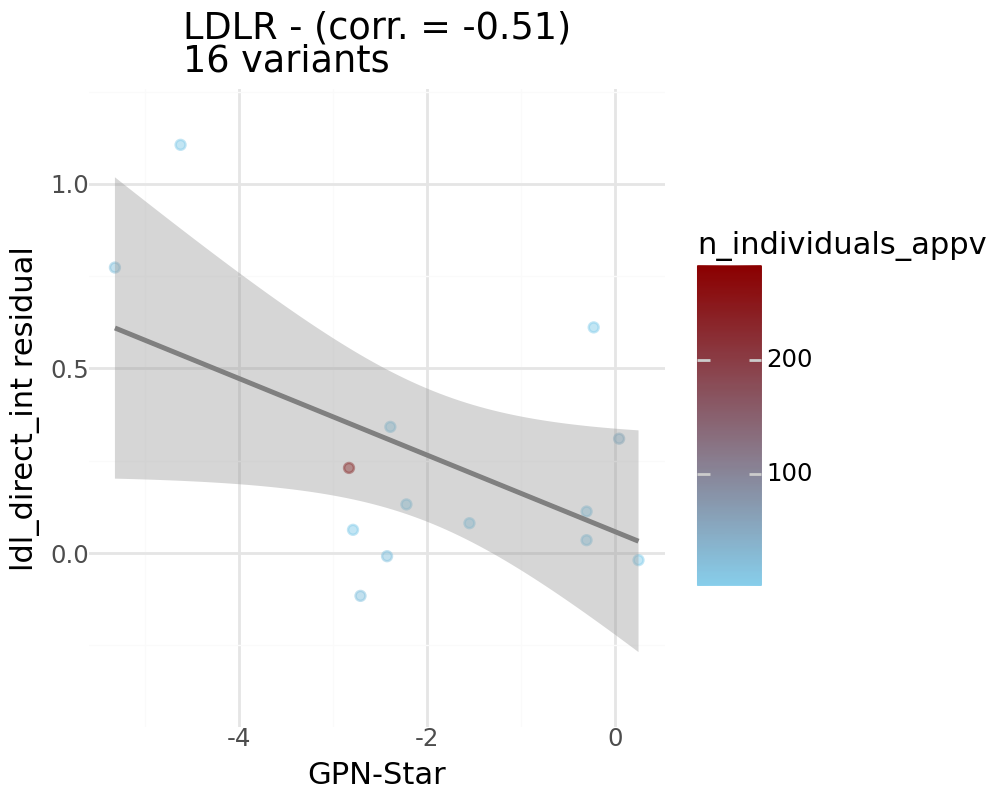

In [36]:
annotation = 'gpn_star_llr_calibrated_mean'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    ogp_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals_appv')) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='skyblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)